# DBSCAN (DENSITY-BASED SPATIAL CLUSTERING OF APPLICATIONS WITH NOISE)
## Seeds (Bugday Tohumu) Veri Seti Uzerinde Uygulama

Bu calismada DBSCAN algoritmasi, Seeds veri seti uzerinde uygulanacaktir.

---
## 1. GEREKLI KUTUPHANELERIN YUKLENMESI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Kutuphaneler basariyla yuklendi.')

Kutuphaneler basariyla yuklendi.


---
## 2. VERI SETININ YUKLENMESI VE KESFI

In [2]:
columns = ['Area', 'Perimeter', 'Compactness', 'Kernel_Length', 'Kernel_Width',
           'Asymmetry_Coeff', 'Kernel_Groove_Length', 'Class']
df = pd.read_csv('data/seeds_dataset.txt', sep=r'\s+', header=None, names=columns)
print(f'Veri seti boyutu: {df.shape}')
print(f'Sutun sayisi: {len(df.columns)}')
print(f'Satir sayisi: {len(df)}')

Veri seti boyutu: (210, 8)
Sutun sayisi: 8
Satir sayisi: 210


In [3]:
df.head()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,Kernel_Groove_Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Area                  210 non-null    float64
 1   Perimeter             210 non-null    float64
 2   Compactness           210 non-null    float64
 3   Kernel_Length         210 non-null    float64
 4   Kernel_Width          210 non-null    float64
 5   Asymmetry_Coeff       210 non-null    float64
 6   Kernel_Groove_Length  210 non-null    float64
 7   Class                 210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [5]:
df.describe()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,Kernel_Groove_Length,Class
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [6]:
print('Eksik deger sayilari:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nToplam eksik deger: {df.isnull().sum().sum()}')

Eksik deger sayilari:
Series([], dtype: int64)

Toplam eksik deger: 0


---
## 3. VERI ON ISLEME

In [7]:
X = df.drop('Class', axis=1)
y_true = df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Olceklendirilmis veri (ilk 5 satir):')
X_scaled.head()

Olceklendirilmis veri (ilk 5 satir):


,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coeff,Kernel_Groove_Length
0,0.142098,0.215462,0.000061,0.304218,0.141702,-0.986152,-0.383577
1,0.011188,0.008224,0.428515,-0.168625,0.197432,-1.788166,-0.922013
2,-0.192067,-0.360201,1.442383,-0.763637,0.208048,-0.667479,-1.189192
3,-0.347091,-0.475333,1.039381,-0.688978,0.319508,-0.960818,-1.229983
4,0.445257,0.330595,1.374509,0.066666,0.805159,-1.563495,-0.475356


---
## 4. DBSCAN (DENSITY-BASED SPATIAL CLUSTERING OF APPLICATIONS WITH NOISE)

Algoritma açıklaması ve teorik detaylar için bkz. **`KONU_ANLATIMI.md`**

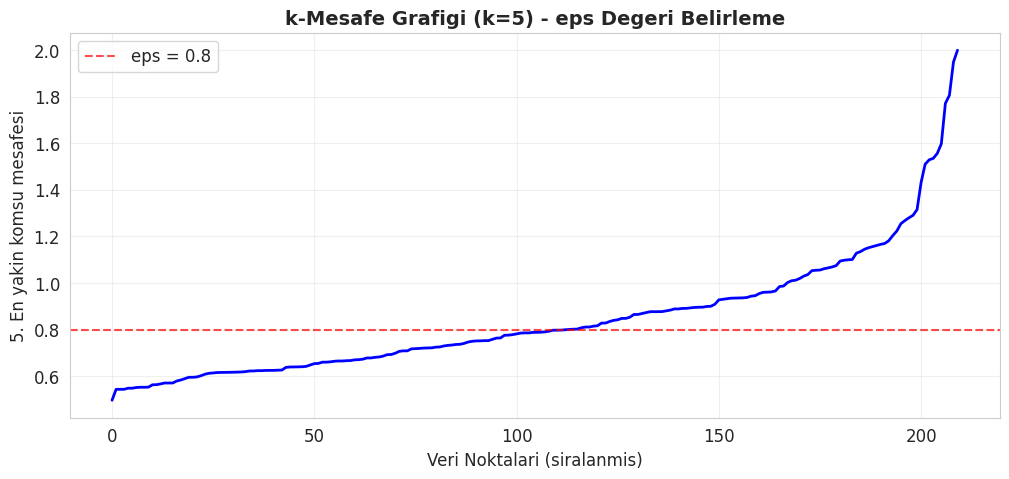

In [8]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='eps = 0.8')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 0.8, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Kumeleme Sonuclari:
eps: 0.8, min_samples: 5
Olusan kume sayisi: 3
Gurultu (aykiri deger) sayisi: 59
Gurultu orani: 28.10%
Silhouette Skoru: 0.1548
Davies-Bouldin Indeksi: 2.1794
Calinski-Harabasz Skoru: 51.5645

Kume dagilimi:
-1     59
 0    107
 1     15
 2     29
Name: count, dtype: int64


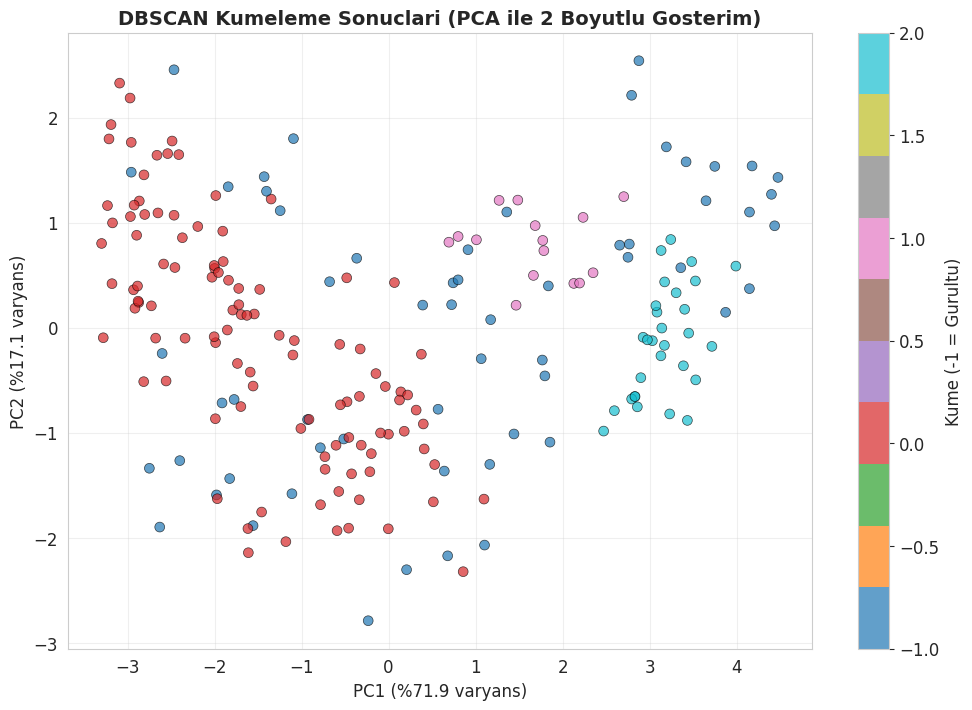

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

---
## 5. GERCEK ETIKETLERLE KARSILASTIRMA

Seeds veri setinde her tohumun gercek cesidi (Class: 1, 2, 3) bilinmektedir.
DBSCAN'in bulmus oldugu kumeler (gurultu noktalari haric), gercek siniflarla Adjusted Rand Index (ARI) kullanilarak karsilastirilabilir.

Adjusted Rand Index (DBSCAN vs Gercek Siniflar): 0.2730


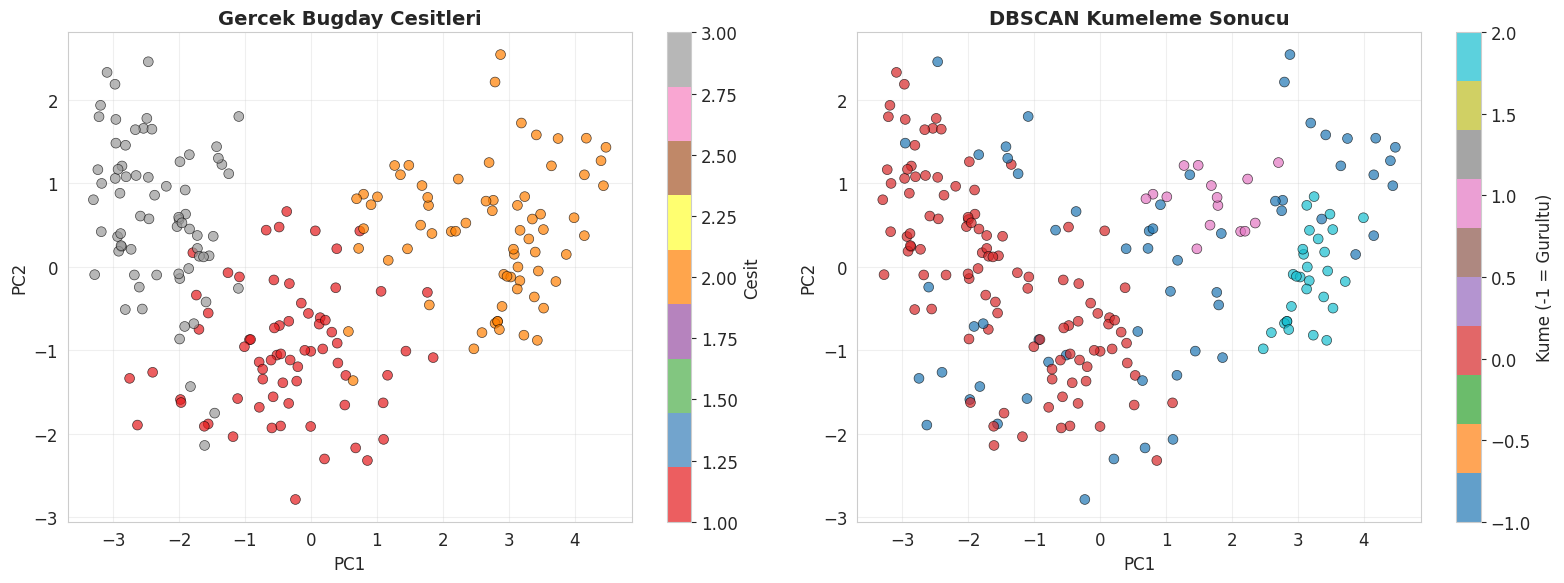

In [11]:
ari_score = adjusted_rand_score(y_true, dbscan_labels)
print(f'Adjusted Rand Index (DBSCAN vs Gercek Siniflar): {ari_score:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='Set1',
                            alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
axes[0].set_title('Gercek Bugday Cesitleri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Cesit')
axes[0].grid(True, alpha=0.3)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                            alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
axes[1].set_title('DBSCAN Kumeleme Sonucu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Kume (-1 = Gurultu)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. SONUC VE DEGERLENDIRME

- Seeds veri seti uzerinde DBSCAN, eps=0.8 ve min_samples=5 parametreleri ile uygulanmistir.
- Algoritma, kume sayisini onceden belirtmeden kumeleri kendisi tespit etmistir.
- Bazi veri noktalari gurultu (-1) olarak isaretlenmistir; bu noktalar diger kumeler arasindaki gecis bolgelerinde yer alan tohumlardir.
- K-Means ve Hiyerarsik Kumeleme ile karsilastirildiginda, DBSCAN'in bu veri seti icin daha dusuk performans gosterdigi (dusuk silhouette skoru) gorulmektedir; cunku Seeds veri setindeki kumeler yaklasik esit yogunluga ve kureye yakin sekle sahiptir, bu da DBSCAN yerine K-Means gibi algoritmalari daha uygun kilar.
- DBSCAN'in en buyuk avantaji, aykiri deger tespiti gerektiren senaryolarda (orn. anomali tespiti) devreye girmesidir.